# Leitura e comparação de espectros

Este notebook procura lê os espectros dentro de `data/raw` e `data/processed`, compara os pares com o mesmo nome base e plota os gráficos lado a lado.

In [ ]:
import os
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import scienceplots
    plt.style.use(['science', 'no-latex'])
except Exception:
    plt.style.use('default')

plt.rcParams.update({
    'figure.dpi': 140,
    'axes.grid': True,
    'grid.alpha': 0.18,
    'grid.linestyle': '--',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 1.0,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'lines.linewidth': 1.6,
    'legend.frameon': False,
})

In [ ]:
RAW_DIR = "../data/raw"
PROCESSED_DIR = "../data/processed"

def read_spectrum(path):
    ext = os.path.splitext(path)[1].lower()

    if ext == ".json":
        data = json.load(open(path, encoding="utf-8"))
        s = data["spectrum"]

        x = np.asarray(s["x"], dtype=float)
        y = np.asarray(s["y"], dtype=float)

        if y.ndim == 2:
            y = y[0]

    else:
        sep = "\t" if ext == ".tsv" else r"[;,\t\s]+"

        df = pd.read_csv(
            path,
            sep=sep,
            engine="python",
            comment="#",
            header=None
        ).dropna(how="all")

        x = pd.to_numeric(df.iloc[:, 0]).to_numpy()
        y = pd.to_numeric(df.iloc[:, 1]).to_numpy()

    return x, y

def list_files(folder):
    files = {}

    for root, _, filenames in os.walk(folder):
        for file in filenames:
            ext = os.path.splitext(file)[1].lower()

            if ext == ".json":
                files[os.path.splitext(file)[0]] = os.path.join(root, file)

    return files

raw_files = list_files(RAW_DIR)
processed_files = list_files(PROCESSED_DIR)

pairs = sorted(
    (k, raw_files[k], processed_files[k])
    for k in raw_files.keys() & processed_files.keys()
)

print(f"Pares encontrados: {len(pairs)}", end="\n\n")

for name, raw_path, processed_path in pairs[:10]:
    print(name)

Pares encontrados: 8

CeraDePolietileno-633nm
CeraDePolietileno-785nm
PE_glicol_mm10000
PE_glicol_mm4000
PVA_altaMM
PVA_mediaMM
Poliisopreno_trans_633nm
Poliisopreno_trans_785nm


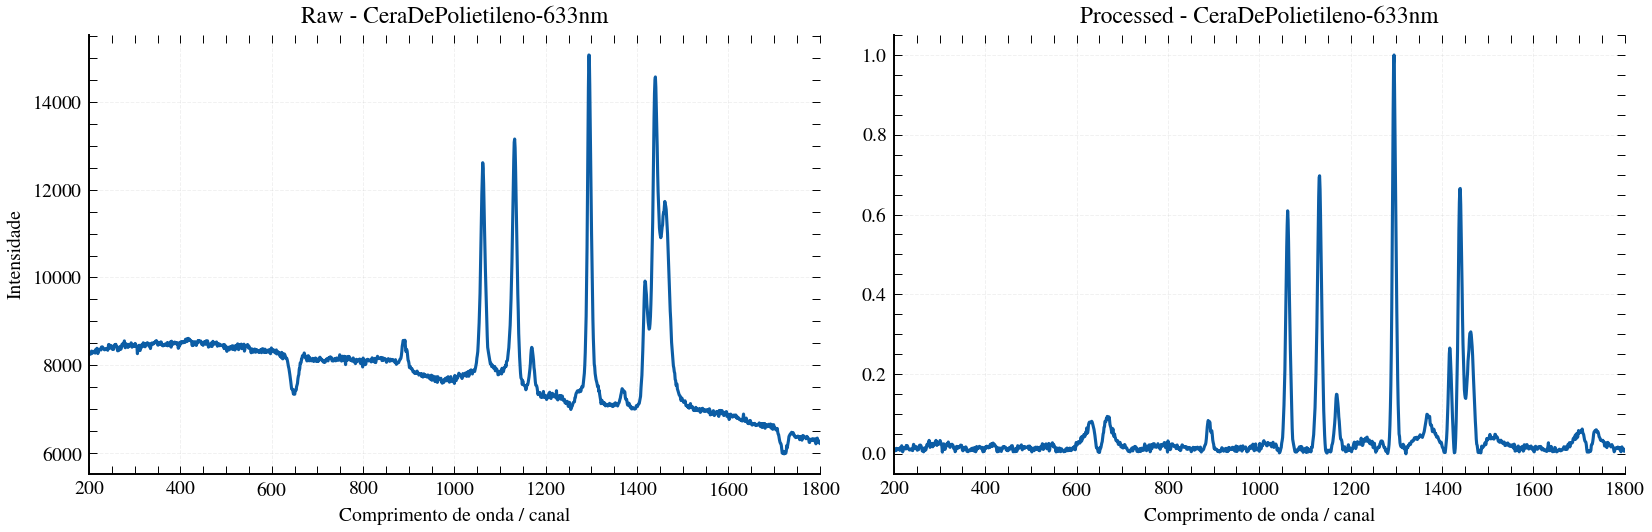

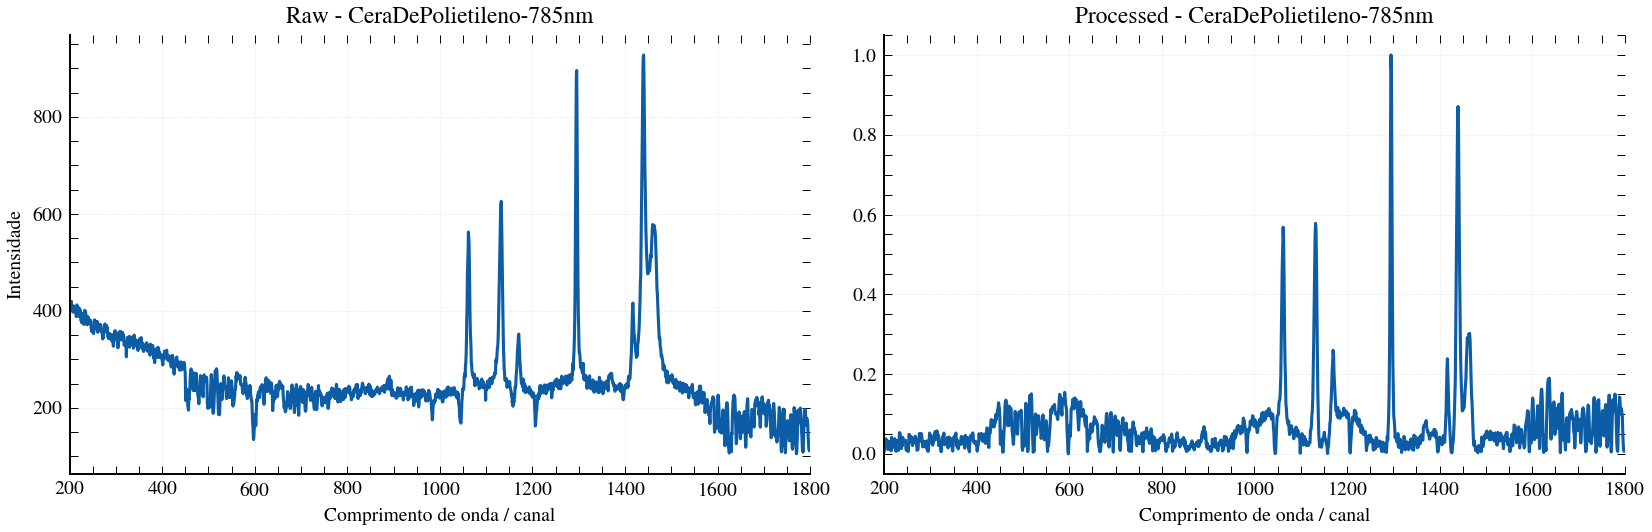

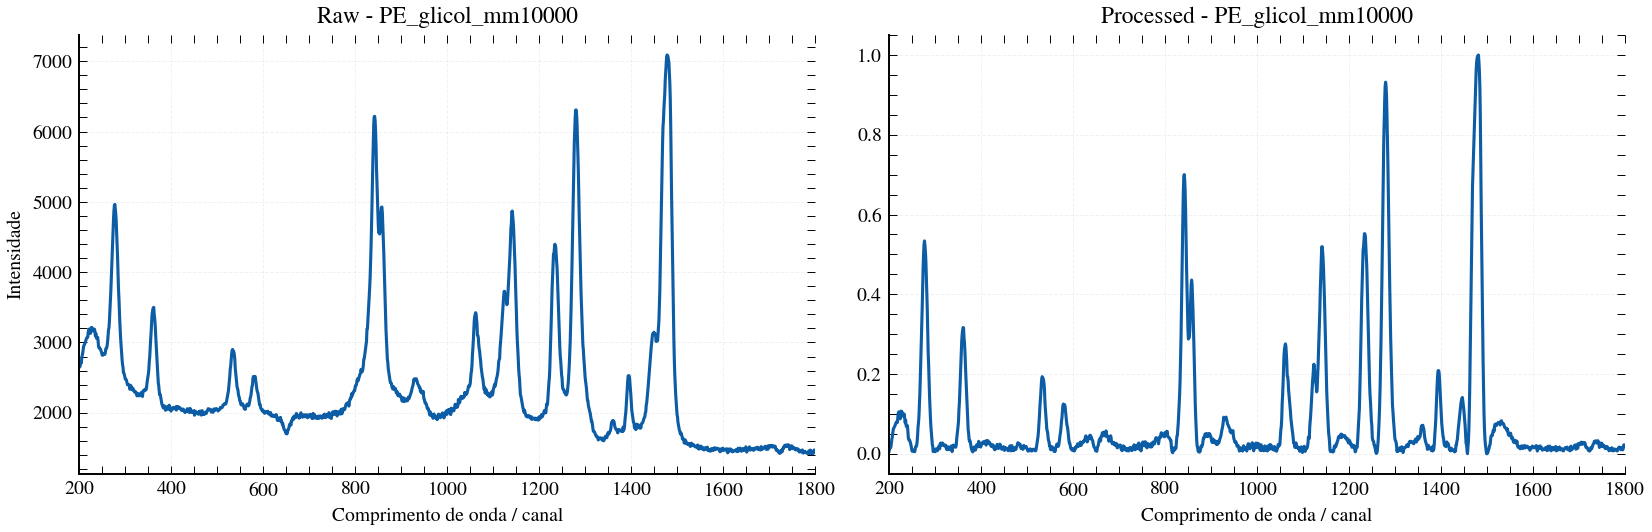

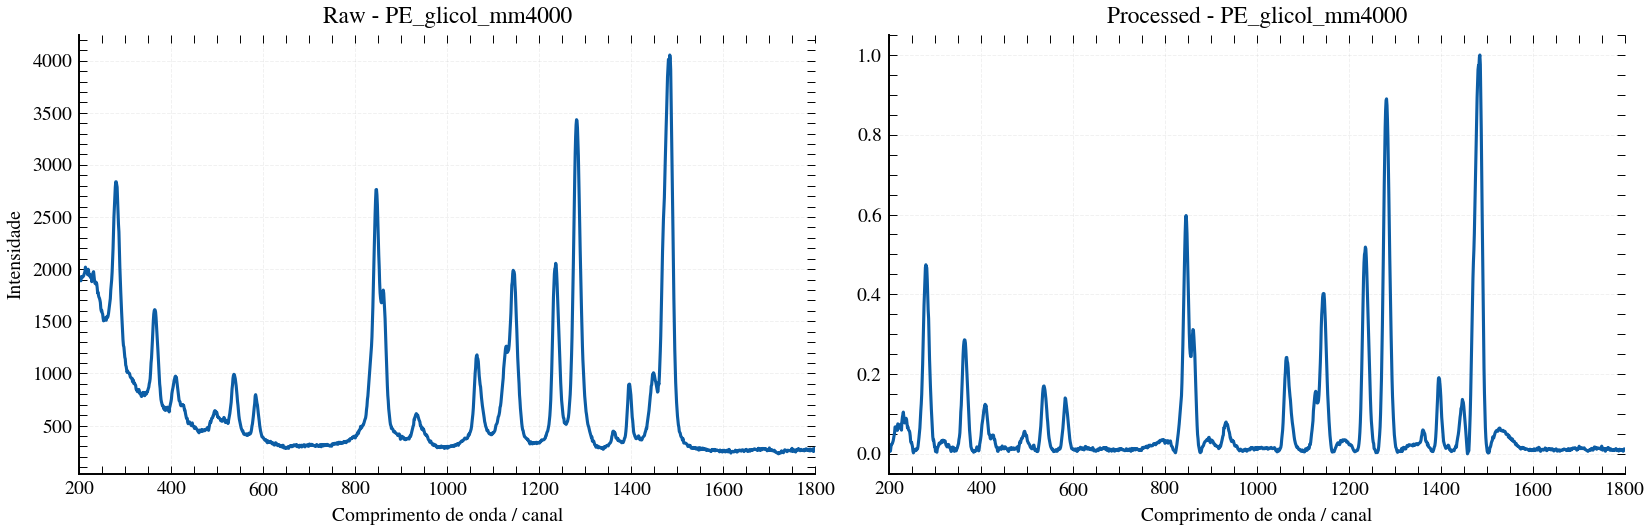

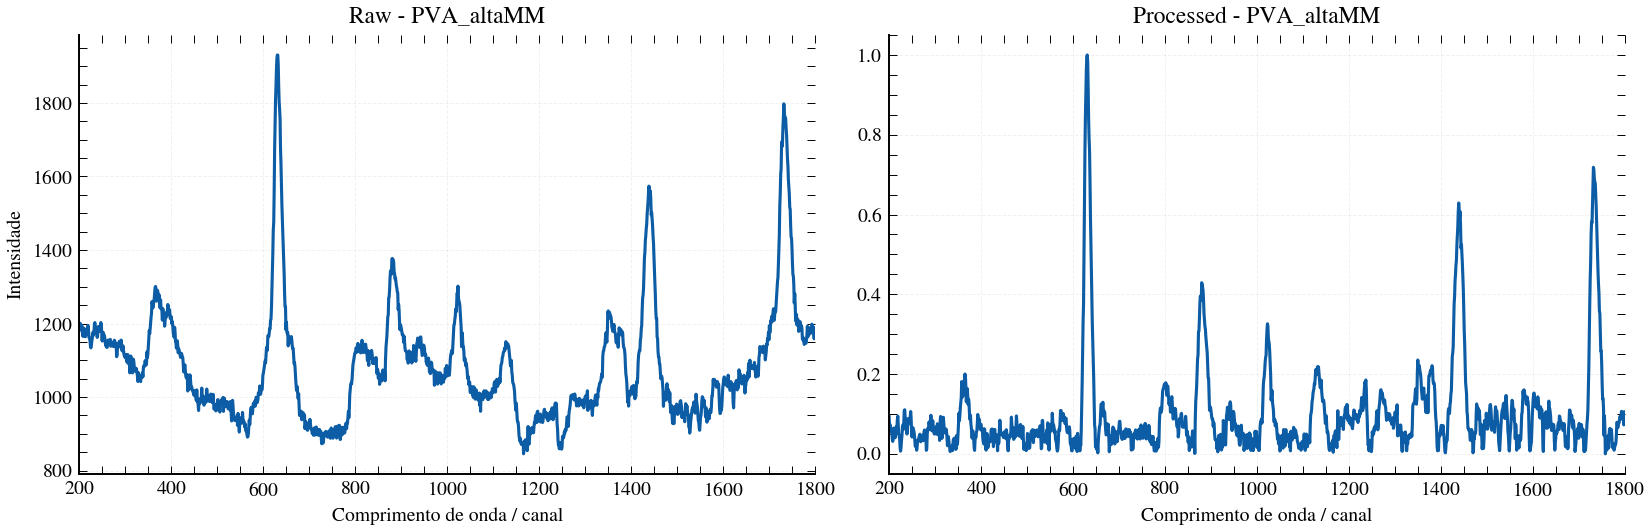

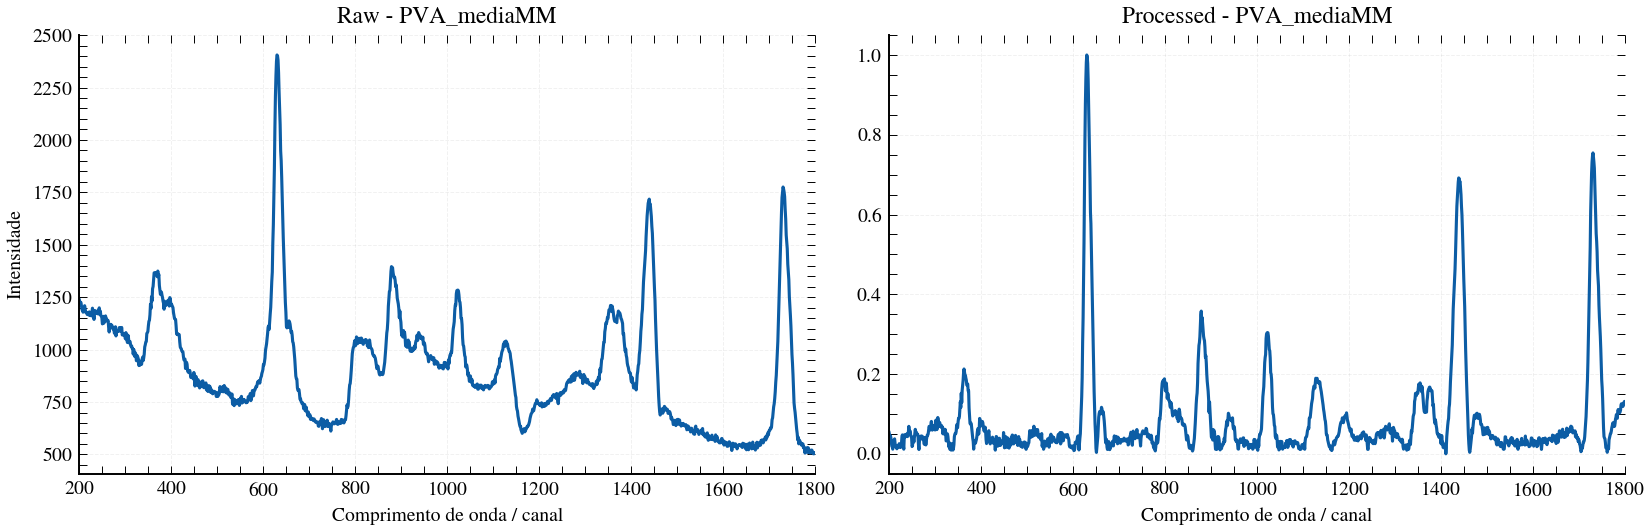

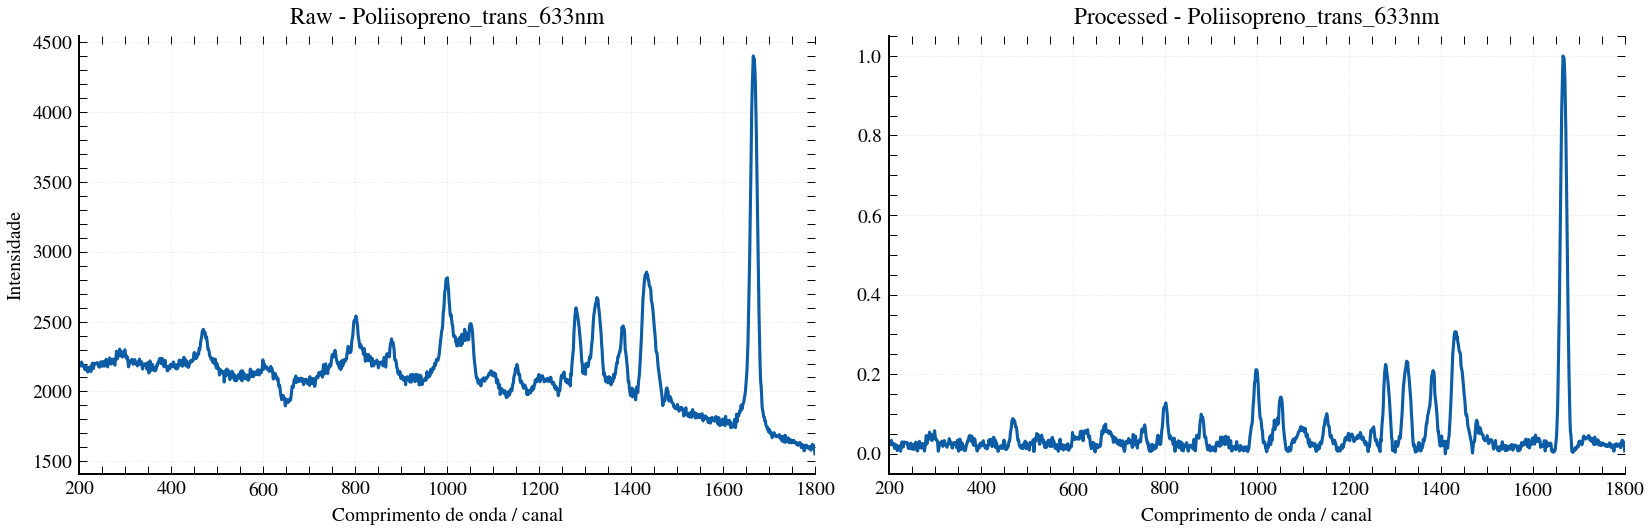

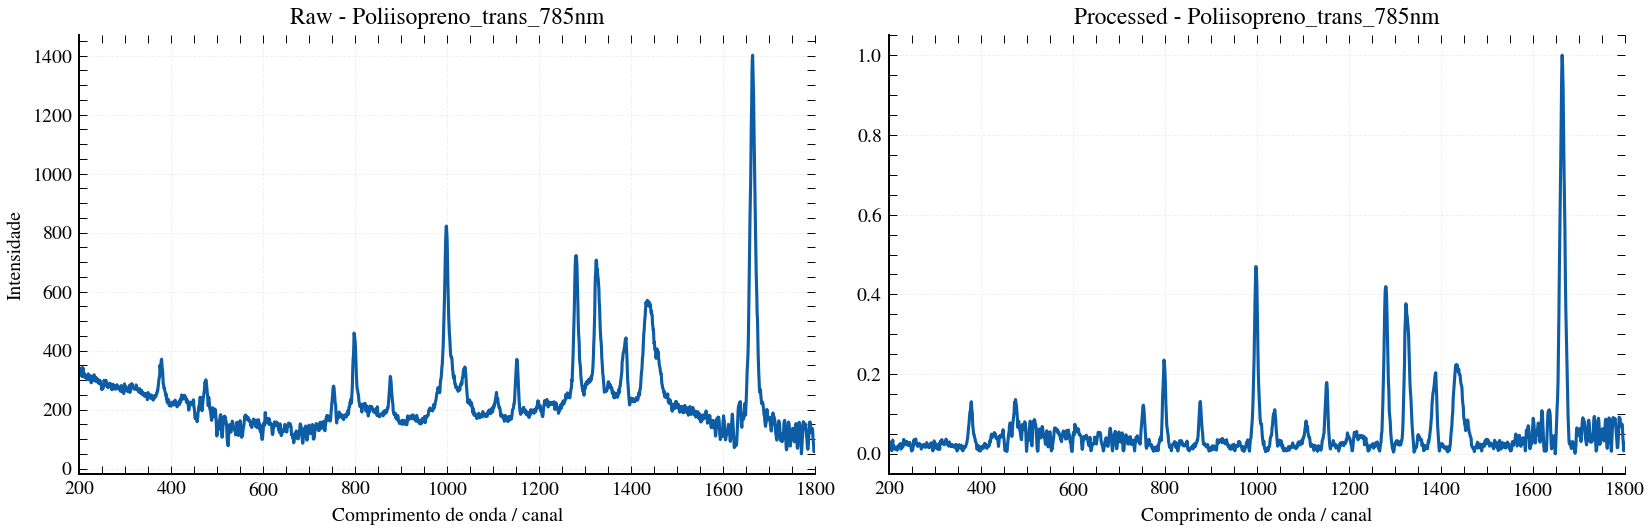

In [ ]:
def plot_pair(name, raw_path, processed_path):
    x_raw, y_raw = read_spectrum(raw_path)
    x_proc, y_proc = read_spectrum(processed_path)

    mask_raw = (x_raw >= 200) & (x_raw <= 1800)
    mask_proc = (x_proc >= 200) & (x_proc <= 1800)

    x_raw, y_raw = x_raw[mask_raw], y_raw[mask_raw]
    x_proc, y_proc = x_proc[mask_proc], y_proc[mask_proc]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

    axes[0].plot(x_raw, y_raw)
    axes[0].set_title(f'Raw - {name}')
    axes[0].set_xlabel('Comprimento de onda / canal')
    axes[0].set_ylabel('Intensidade')
    axes[0].set_xlim(200, 1800)
    axes[0].minorticks_on()

    axes[1].plot(x_proc, y_proc)
    axes[1].set_title(f'Processed - {name}')
    axes[1].set_xlabel('Comprimento de onda / canal')
    axes[1].set_xlim(200, 1800)
    axes[1].minorticks_on()

    for ax in axes:
        ax.tick_params(which='both', length=4)
        ax.grid(True, which='major')

    fig.tight_layout()
    plt.show()

for name, raw_path, processed_path in pairs:
    plot_pair(name, raw_path, processed_path)